Using: cuda
Temperature sweep:
   T (K)    Vt (eV)
----------------------
     200     0.0172
     225     0.0194
     250     0.0215
     275     0.0237
     300     0.0259
     325     0.0280
     350     0.0302
     375     0.0323
     400     0.0345

Morphology: σ=4  donor=50.0%

TEMPERATURE SWEEP — 200K to 400K

  T=200K  Vt=0.0172
    Jsc=0.021329  Voc=0.2577  J_var=2.90e-06

  T=225K  Vt=0.0194
    Jsc=0.027735  Voc=0.2975  J_var=2.43e-06

  T=250K  Vt=0.0215
    Jsc=0.026530  Voc=0.3292  J_var=5.24e-06

  T=275K  Vt=0.0237
    Jsc=0.022365  Voc=0.3560  J_var=2.30e-06

  T=300K  Vt=0.0259
    Jsc=0.035611  Voc=0.4064  J_var=5.37e-06

  T=325K  Vt=0.0280
    Jsc=0.030439  Voc=0.4337  J_var=2.95e-06

  T=350K  Vt=0.0302
    Jsc=0.030362  Voc=0.4669  J_var=1.89e-06

  T=375K  Vt=0.0323
    Jsc=0.029416  Voc=0.4987  J_var=4.68e-06

  T=400K  Vt=0.0345
    Jsc=0.028957  Voc=0.5312  J_var=1.21e-06

   T (K)    Vt (eV)        Jsc    Voc (V)
---------------------------------------------

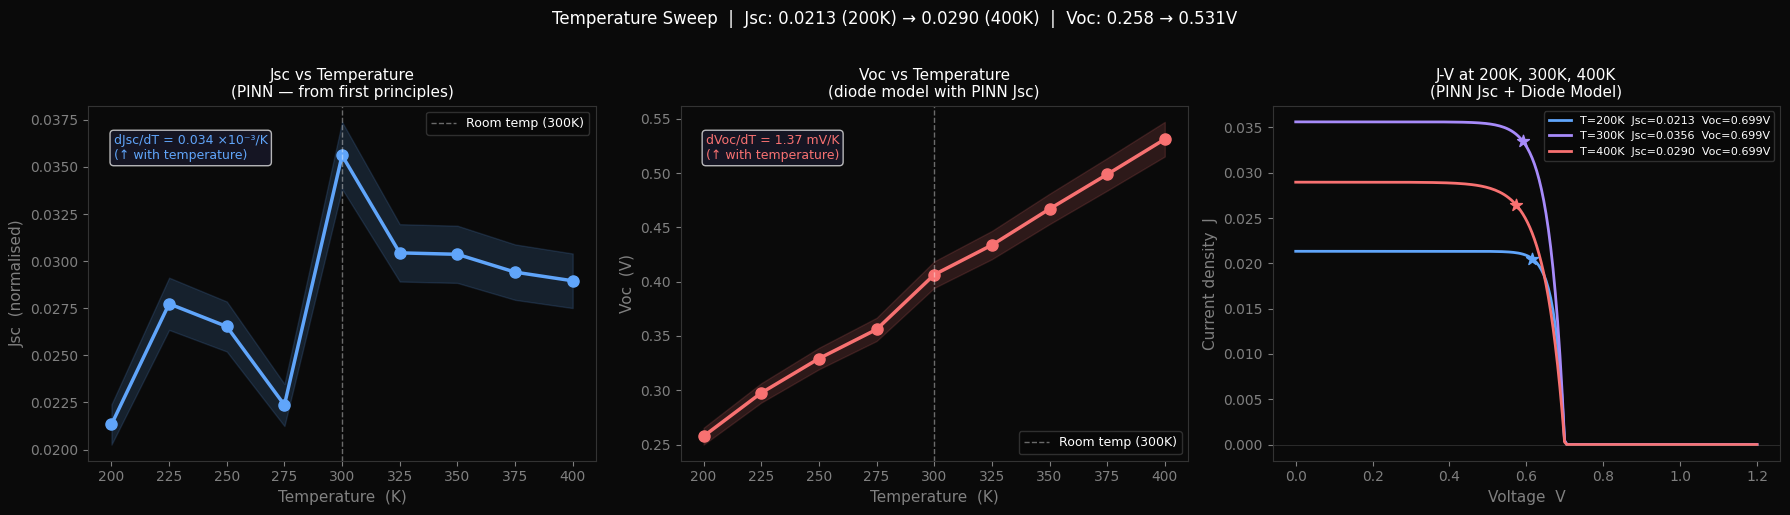


Saved temperature_sweep_results.npy


In [1]:
# ============================================
# TEMPERATURE SWEEP
# Vt = kT/q varies with temperature
# Sweep 200K to 400K in steps of 25K
# Record Jsc and Voc at each temperature
# ============================================
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

# ============================================
# CONSTANTS — Vt will vary, rest fixed
# ============================================
N_grid  = 32
q       = 1.0
mu_n    = 1.0
mu_p    = 1.0
mu_X    = 1.0
k_rec   = 0.1
k_diss  = 5.0
G       = 0.1
k_B     = 8.617e-5   # Boltzmann constant in eV/K

# Temperature sweep
temperatures  = np.arange(200, 425, 25)   # 200K to 400K step 25K
Vt_values     = k_B * temperatures        # Vt = kT/q in eV

print("Temperature sweep:")
print(f"{'T (K)':>8} {'Vt (eV)':>10}")
print("-" * 22)
for T, Vt in zip(temperatures, Vt_values):
    print(f"{T:>8.0f} {Vt:>10.4f}")

# ============================================
# FIXED MORPHOLOGY — σ=4, seed=42
# ============================================
np.random.seed(42)
noise     = np.random.randn(N_grid, N_grid)
smoothed  = gaussian_filter(noise, sigma=4)
threshold = np.percentile(smoothed, 50)
M_np      = (smoothed > threshold).astype(float)
M_flat    = torch.tensor(
    M_np.flatten(), dtype=torch.float32
).reshape(-1, 1).to(device)

print(f"\nMorphology: σ=4  donor={M_np.mean():.1%}")

# ============================================
# NETWORK
# ============================================
def make_net(hidden=128):
    net = nn.Sequential(
        nn.Linear(3, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden), nn.Tanh(),
        nn.Linear(hidden, 1)
    )
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    return net

class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.phi_net = make_net()
        self.n_net   = make_net()
        self.p_net   = make_net()
        self.X_net   = make_net()

    def forward(self, coords, M):
        inp = torch.cat([coords, M], dim=1)
        x   = coords[:, 0:1]
        phi = x  +  x * (1 - x) * self.phi_net(inp)
        n   = (1 - x) * torch.nn.functional.softplus(self.n_net(inp))
        p   = x       * torch.nn.functional.softplus(self.p_net(inp) + 1.0)
        X   =           torch.nn.functional.softplus(self.X_net(inp))
        return phi, n, p, X

# ============================================
# HELPERS
# ============================================
def grad(f, coords):
    return torch.autograd.grad(
        f, coords,
        grad_outputs=torch.ones_like(f),
        create_graph=True, retain_graph=True)[0]

def laplacian(f, coords):
    g   = grad(f, coords)
    gxx = grad(g[:, 0:1], coords)[:, 0:1]
    gyy = grad(g[:, 1:2], coords)[:, 1:2]
    return gxx + gyy

def divergence(Fx, Fy, coords):
    return (grad(Fx, coords)[:, 0:1] +
            grad(Fy, coords)[:, 1:2])

def fresh_coords():
    x_lin  = torch.linspace(0, 1, N_grid)
    y_lin  = torch.linspace(0, 1, N_grid)
    Xg, Yg = torch.meshgrid(x_lin, y_lin, indexing='ij')
    c = torch.stack([Xg, Yg], dim=-1).reshape(-1, 2).to(device)
    c.requires_grad_(True)
    return c

# ============================================
# COMPUTE ALL — Vt is now a parameter
# ============================================
def compute_all(coords, M_flat, model, Vt):
    phi, n, p, X = model(coords, M_flat)

    grad_phi = grad(phi, coords)
    grad_n   = grad(n,   coords)
    grad_p   = grad(p,   coords)
    grad_X   = grad(X,   coords)
    lap_phi  = laplacian(phi, coords)
    lap_X    = laplacian(X,   coords)

    # Current densities — Vt scales diffusion
    Jn_x = -q*n*mu_n*grad_phi[:,0:1] + q*Vt*mu_n*grad_n[:,0:1]
    Jn_y = -q*n*mu_n*grad_phi[:,1:2] + q*Vt*mu_n*grad_n[:,1:2]
    Jp_x = -q*p*mu_p*grad_phi[:,0:1] - q*Vt*mu_p*grad_p[:,0:1]
    Jp_y = -q*p*mu_p*grad_phi[:,1:2] - q*Vt*mu_p*grad_p[:,1:2]

    div_Jn    = divergence(Jn_x, Jn_y, coords)
    div_Jp    = divergence(Jp_x, Jp_y, coords)

    R         = k_rec  * n * p
    R_X       = k_rec  * X
    field_mag = torch.norm(grad_phi, dim=1, keepdim=True)
    D_term    = k_diss * X * field_mag
    G_field   = G * M_flat

    L_p = torch.mean((lap_phi  - q*(n - p))**2)
    L_e = torch.mean((div_Jn   - R + D_term)**2)
    L_h = torch.mean((-div_Jp  - R + D_term)**2)

    # Vt scales exciton diffusion too
    L_x = torch.mean((Vt*mu_X*lap_X - D_term - R_X + G_field)**2)

    y_c    = coords[:, 1]
    y0     = y_c < (1.0/N_grid)
    y1     = y_c > (1.0 - 1.0/N_grid)
    L_xbc  = (torch.mean(grad_X[y0, 1:2]**2) +
               torch.mean(grad_X[y1, 1:2]**2))
    L_pbc  = (torch.mean(grad_phi[y0, 1:2]**2) +
               torch.mean(grad_phi[y1, 1:2]**2))
    L_nd   = torch.mean((n * M_flat)**2)
    L_pd   = torch.mean((p * (1 - M_flat))**2)
    L_cons = torch.var(Jn_x + Jp_x)

    return (L_p, L_e, L_h, L_x, L_xbc,
            L_pbc, L_nd, L_pd, L_cons, Jn_x, Jp_x)

# ============================================
# TRAIN AT ONE TEMPERATURE
# ============================================
def train_at_temperature(T, Vt):
    print(f"\n  T={T:.0f}K  Vt={Vt:.4f}")

    model = PINN2D().to(device)

    # Phase 1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(2000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, *_ = compute_all(c, M_flat, model, Vt)
        L_p.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 2
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    for epoch in range(3000):
        opt.zero_grad()
        c = fresh_coords()
        L_p, L_e, L_h, *_ = compute_all(c, M_flat, model, Vt)
        loss = L_p + L_e + L_h
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

    # Phase 3
    opt = torch.optim.Adam(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000)
    for epoch in range(15000):
        opt.zero_grad()
        c = fresh_coords()
        (L_p, L_e, L_h, L_x, L_xbc,
         L_pbc, L_nd, L_pd,
         L_cons, Jn_x, Jp_x) = compute_all(c, M_flat, model, Vt)

        loss = (  1.0*L_p  + 1.0*L_e  + 5.0*L_h
                + 1.0*L_x  + 5.0*L_xbc + 5.0*L_pbc
                + 10.0*L_nd + 10.0*L_pd + 50.0*L_cons)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sch.step()

    # Evaluate Jsc
    model.eval()
    c_eval = fresh_coords()
    phi_v, n_v, p_v, X_v = model(c_eval, M_flat)
    gp  = grad(phi_v, c_eval)
    gn  = grad(n_v,   c_eval)
    gpp = grad(p_v,   c_eval)

    Jn_x_v = -q*n_v*mu_n*gp[:,0:1]  + q*Vt*mu_n*gn[:,0:1]
    Jp_x_v = -q*p_v*mu_p*gp[:,0:1]  - q*Vt*mu_p*gpp[:,0:1]
    Jtot   =  Jn_x_v + Jp_x_v

    Jsc   = -float(Jtot.reshape(N_grid,N_grid)[-1,:].mean().detach())
    J_var = float(torch.var(Jtot).detach())

    # Compute Voc from diode model
    # Voc = n_ideal * Vt * ln(Jsc/J0 + 1)
    # Use n_ideal=1.5, J0 calibrated at room temperature (300K)
    n_ideal   = 1.5
    J0_300K   = 1e-6    # fixed reference dark current
    if Jsc > 1e-6:
        Voc = n_ideal * Vt * np.log(Jsc / J0_300K + 1)
    else:
        Voc = 0.0

    print(f"    Jsc={max(Jsc,0):.6f}  Voc={Voc:.4f}  J_var={J_var:.2e}")
    return max(Jsc, 0.0), Voc, J_var

# ============================================
# RUN SWEEP
# ============================================
print("\n" + "="*55)
print("TEMPERATURE SWEEP — 200K to 400K")
print("="*55)

results = []
for T, Vt in zip(temperatures, Vt_values):
    Jsc, Voc, J_var = train_at_temperature(T, Vt)
    results.append({
        'T':     T,
        'Vt':    Vt,
        'Jsc':   Jsc,
        'Voc':   Voc,
        'J_var': J_var,
    })

T_arr   = np.array([r['T']   for r in results])
Vt_arr  = np.array([r['Vt']  for r in results])
Jsc_arr = np.array([r['Jsc'] for r in results])
Voc_arr = np.array([r['Voc'] for r in results])

# ============================================
# PRINT SUMMARY TABLE
# ============================================
print(f"\n{'='*60}")
print(f"{'T (K)':>8} {'Vt (eV)':>10} {'Jsc':>10} {'Voc (V)':>10}")
print(f"{'-'*60}")
for r in results:
    print(f"{r['T']:>8.0f} {r['Vt']:>10.4f} "
          f"{r['Jsc']:>10.4f} {r['Voc']:>10.4f}")
print(f"{'='*60}")

# Trends
print(f"\nTrends across 200K → 400K:")
print(f"  Jsc:  {Jsc_arr[0]:.4f} → {Jsc_arr[-1]:.4f}  "
      f"({'↑' if Jsc_arr[-1] > Jsc_arr[0] else '↓'} "
      f"{abs(Jsc_arr[-1]-Jsc_arr[0])/Jsc_arr[0]*100:.1f}%)")
print(f"  Voc:  {Voc_arr[0]:.4f} → {Voc_arr[-1]:.4f}  "
      f"({'↑' if Voc_arr[-1] > Voc_arr[0] else '↓'} "
      f"{abs(Voc_arr[-1]-Voc_arr[0])/max(Voc_arr[0],1e-9)*100:.1f}%)")

# ============================================
# VISUALIZATION
# ============================================
BG = '#0a0a0a'
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor(BG)

# --- Panel 1: Jsc vs Temperature ---
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(T_arr, Jsc_arr,
        color='#60a5fa', linewidth=2.5,
        marker='o', markersize=8)
ax.fill_between(T_arr,
                Jsc_arr * 0.95,
                Jsc_arr * 1.05,
                alpha=0.15, color='#60a5fa')

# Mark room temperature
ax.axvline(x=300, color='white', linewidth=1,
           linestyle='--', alpha=0.4,
           label='Room temp (300K)')

# Trend annotation
slope = np.polyfit(T_arr, Jsc_arr, 1)[0]
sign  = '↑' if slope > 0 else '↓'
ax.annotate(
    f'dJsc/dT = {slope*1000:.3f} ×10⁻³/K\n({sign} with temperature)',
    xy=(0.05, 0.85), xycoords='axes fraction',
    color='#60a5fa', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.7)
)

ax.set_xlabel('Temperature  (K)', color='gray', fontsize=11)
ax.set_ylabel('Jsc  (normalised)', color='gray', fontsize=11)
ax.set_title('Jsc vs Temperature\n(PINN — from first principles)',
             color='white', fontsize=11)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax.tick_params(colors='gray')
for s in ax.spines.values(): s.set_edgecolor('#333333')

# --- Panel 2: Voc vs Temperature ---
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.plot(T_arr, Voc_arr,
         color='#f87171', linewidth=2.5,
         marker='o', markersize=8)
ax2.fill_between(T_arr,
                 Voc_arr * 0.97,
                 Voc_arr * 1.03,
                 alpha=0.15, color='#f87171')
ax2.axvline(x=300, color='white', linewidth=1,
            linestyle='--', alpha=0.4,
            label='Room temp (300K)')

slope_voc = np.polyfit(T_arr, Voc_arr, 1)[0]
ax2.annotate(
    f'dVoc/dT = {slope_voc*1000:.2f} mV/K\n'
    f'({"↑" if slope_voc > 0 else "↓"} with temperature)',
    xy=(0.05, 0.85), xycoords='axes fraction',
    color='#f87171', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.7)
)

ax2.set_xlabel('Temperature  (K)', color='gray', fontsize=11)
ax2.set_ylabel('Voc  (V)', color='gray', fontsize=11)
ax2.set_title('Voc vs Temperature\n(diode model with PINN Jsc)',
              color='white', fontsize=11)
ax2.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax2.tick_params(colors='gray')
for s in ax2.spines.values(): s.set_edgecolor('#333333')

# --- Panel 3: J-V curves at 3 temperatures ---
ax3 = axes[2]
ax3.set_facecolor(BG)

n_ideal   = 1.5
V_sweep   = np.linspace(0.0, 1.2, 200)
colors_T  = ['#60a5fa', '#a78bfa', '#f87171']
T_select  = [200, 300, 400]

for T_sel, color in zip(T_select, colors_T):
    # Find closest result
    idx  = np.argmin(np.abs(T_arr - T_sel))
    Jsc  = Jsc_arr[idx]
    Vt_s = Vt_arr[idx]
    if Jsc < 1e-6:
        continue
    J0   = Jsc / (np.exp(0.7/(n_ideal*Vt_s)) - 1)
    J    = np.clip(Jsc - J0*(np.exp(V_sweep/(n_ideal*Vt_s))-1), 0, None)
    P    = J * V_sweep
    idx_mpp = np.argmax(P)
    sc   = np.where(np.diff(np.sign(J)))[0]
    Voc  = V_sweep[sc[0]] if len(sc) > 0 else 0.7
    FF   = P[idx_mpp]/(Voc*Jsc) if Voc*Jsc > 0 else 0

    ax3.plot(V_sweep, J, color=color, linewidth=2.0,
             label=f'T={T_arr[idx]:.0f}K  '
                   f'Jsc={Jsc:.4f}  Voc={Voc:.3f}V')
    ax3.scatter([V_sweep[idx_mpp]], [J[idx_mpp]],
                color=color, s=80, zorder=5, marker='*')

ax3.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
ax3.set_xlabel('Voltage  V', color='gray', fontsize=11)
ax3.set_ylabel('Current density  J', color='gray', fontsize=11)
ax3.set_title('J-V at 200K, 300K, 400K\n(PINN Jsc + Diode Model)',
              color='white', fontsize=11)
ax3.legend(fontsize=8, framealpha=0.2, labelcolor='white')
ax3.tick_params(colors='gray')
for s in ax3.spines.values(): s.set_edgecolor('#333333')

fig.suptitle(
    f'Temperature Sweep  |  '
    f'Jsc: {Jsc_arr[0]:.4f} (200K) → {Jsc_arr[-1]:.4f} (400K)  |  '
    f'Voc: {Voc_arr[0]:.3f} → {Voc_arr[-1]:.3f}V',
    color='white', fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('temperature_sweep.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

# Save results
np.save('temperature_sweep_results.npy', {
    'temperatures': temperatures,
    'Vt_values':    Vt_values,
    'Jsc':          Jsc_arr,
    'Voc':          Voc_arr,
})
print("\nSaved temperature_sweep_results.npy")